# Basic Codes

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("buntyshah/auto-insurance-claims-data")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/auto-insurance-claims-data


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Load dataset
df = pd.read_csv("/kaggle/input/auto-insurance-claims-data/insurance_claims.csv")

# Drop unnecessary columns
df = df.drop(columns=['_c39', 'policy_state', 'authorities_contacted'])

# Drop rows with missing values
df = df.dropna()

# Encode categorical columns
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# Split features and target
X = df.drop('fraud_reported', axis=1)
y = df['fraud_reported']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize models
models = {
    "Random Forest": RandomForestClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "SVM": SVC(),
    "Naive Bayes": GaussianNB()
}




In [ ]:
# Hyperparameter tuning for Random Forest
param_grid_rf = {
    'n_estimators': [50, 100, 150],
    'max_depth': [6, 8, 10, None],
    'min_samples_split': [2, 5, 10]
}

grid_rf = GridSearchCV(RandomForestClassifier(), param_grid_rf, cv=5, scoring='f1', n_jobs=-1)
grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_
models["Random Forest (Tuned)"] = best_rf

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


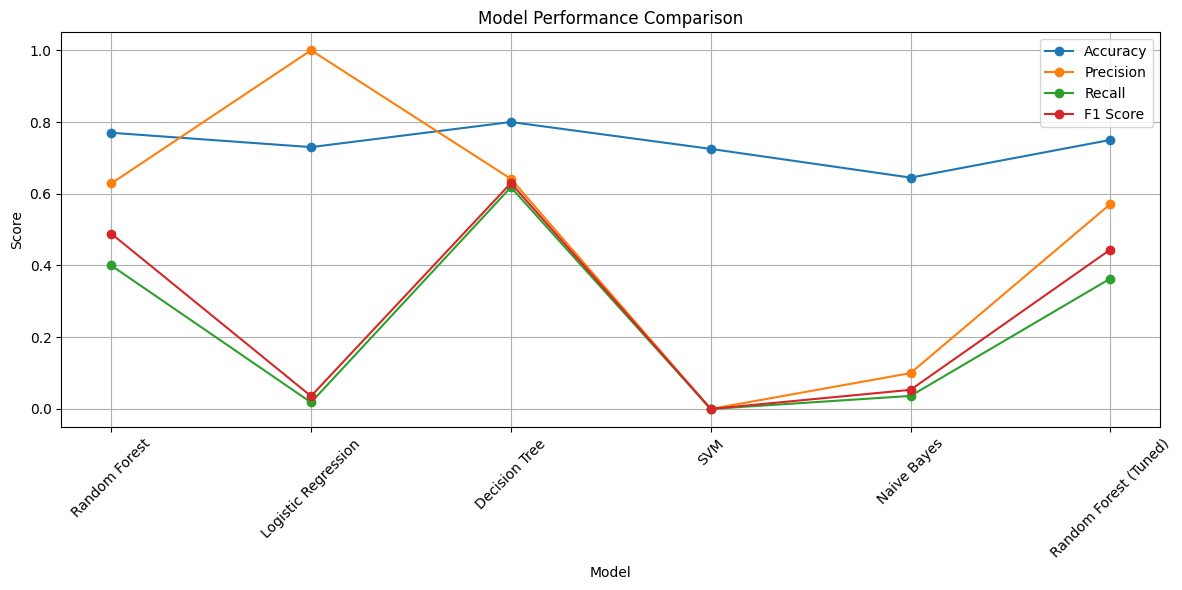

                   Model  Accuracy  Precision    Recall  F1 Score
2          Decision Tree     0.800   0.641509  0.618182  0.629630
0          Random Forest     0.770   0.628571  0.400000  0.488889
5  Random Forest (Tuned)     0.750   0.571429  0.363636  0.444444
4            Naive Bayes     0.645   0.100000  0.036364  0.053333
1    Logistic Regression     0.730   1.000000  0.018182  0.035714
3                    SVM     0.725   0.000000  0.000000  0.000000


In [ ]:
# Evaluate all models
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0)
    })

# Create DataFrame from results
results_df = pd.DataFrame(results)

# Visualize results
plt.figure(figsize=(12, 6))
for metric in ['Accuracy', 'Precision', 'Recall', 'F1 Score']:
    plt.plot(results_df['Model'], results_df[metric], marker='o', label=metric)

plt.title('Model Performance Comparison')
plt.xlabel('Model')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Display table
print(results_df.sort_values(by='F1 Score', ascending=False))

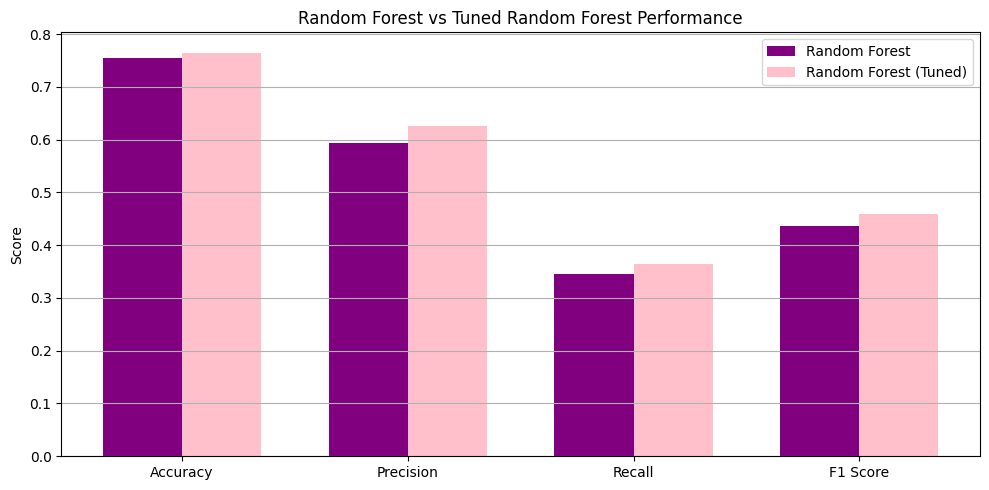

In [ ]:
# Filter out Random Forest and Random Forest (Tuned) results
rf_comparison = results_df[results_df['Model'].str.contains("Random Forest")].copy()

# Plotting comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
x = range(len(metrics))

plt.figure(figsize=(10, 5))
bar_width = 0.35

# Normal RF
plt.bar([i - bar_width/2 for i in x], rf_comparison.iloc[0][metrics], width=bar_width, label='Random Forest', color='purple')

# Tuned RF
plt.bar([i + bar_width/2 for i in x], rf_comparison.iloc[1][metrics], width=bar_width, label='Random Forest (Tuned)', color='pink')

plt.xticks(ticks=x, labels=metrics)
plt.ylabel("Score")
plt.title("Random Forest vs Tuned Random Forest Performance")
plt.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.show()


In [ ]:
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

st.set_page_config(page_title="ML Model Comparator", layout="wide")
st.title("📊 Classification Model Comparator")

uploaded_file = st.file_uploader("Upload a CSV file", type=["csv"])

if uploaded_file is not None:
    df = pd.read_csv(uploaded_file)
    st.subheader("📄 Dataset Preview")
    st.dataframe(df.head())

    st.subheader("🎯 Target Selection")
    target_col = st.selectbox("Select the target column", df.columns)

    if st.button("Run Model Comparison"):
        X = df.drop(target_col, axis=1)
        y = df[target_col]

        # Handle non-numeric columns
        for col in X.select_dtypes(include=['object', 'category']).columns:
            X[col] = LabelEncoder().fit_transform(X[col].astype(str))

        if y.dtype == 'object' or y.dtype.name == 'category':
            y = LabelEncoder().fit_transform(y.astype(str))

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        models = {
            "Logistic Regression": LogisticRegression(max_iter=1000),
            "Decision Tree": DecisionTreeClassifier(),
            "Random Forest": RandomForestClassifier(),
            "Gradient Boosting": GradientBoostingClassifier(),
            "SVM": SVC()
        }

        param_grids = {
            "Logistic Regression": {'C': [0.1, 1, 10]},
            "Decision Tree": {'max_depth': [5, 10, None]},
            "Random Forest": {'n_estimators': [50, 100], 'max_depth': [10, None]},
            "Gradient Boosting": {'n_estimators': [50, 100], 'learning_rate': [0.01, 0.1]},
            "SVM": {'C': [0.1, 1], 'kernel': ['linear', 'rbf']}
        }

        results = []

        for name, model in models.items():
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            results.append({
                "Model": name,
                "Type": "Default",
                "Accuracy": accuracy_score(y_test, y_pred),
                "Precision": precision_score(y_test, y_pred, average='weighted', zero_division=0),
                "Recall": recall_score(y_test, y_pred, average='weighted', zero_division=0),
                "F1 Score": f1_score(y_test, y_pred, average='weighted', zero_division=0)
            })

            grid = GridSearchCV(model, param_grids[name], cv=3, n_jobs=-1)
            grid.fit(X_train, y_train)
            y_pred_tuned = grid.predict(X_test)

            results.append({
                "Model": name,
                "Type": "Tuned",
                "Accuracy": accuracy_score(y_test, y_pred_tuned),
                "Precision": precision_score(y_test, y_pred_tuned, average='weighted', zero_division=0),
                "Recall": recall_score(y_test, y_pred_tuned, average='weighted', zero_division=0),
                "F1 Score": f1_score(y_test, y_pred_tuned, average='weighted', zero_division=0)
            })

        results_df = pd.DataFrame(results)
        st.subheader("📈 Model Comparison Table")
        st.dataframe(results_df)

        st.subheader("📊 Visualization")
        metric = st.selectbox("Select a metric to compare", ["Accuracy", "Precision", "Recall", "F1 Score"])

        plt.figure(figsize=(10, 5))
        sns.barplot(data=results_df, x="Model", y=metric, hue="Type")
        plt.title(f"Model Comparison - {metric}")
        plt.xticks(rotation=45)
        st.pyplot(plt)

        csv = results_df.to_csv(index=False).encode('utf-8')
        st.download_button("📥 Download Results as CSV", data=csv, file_name='model_comparison.csv', mime='text/csv')


ModuleNotFoundError: No module named 'streamlit'